100%|██████████| 50.4M/50.4M [00:01<00:00, 51.5MB/s]

Extracting files...



/tmp/ipython-input-1483987374.py:14: DtypeWarning: Columns (47,73) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"{path}/bottle.csv")


Pregled prvih 5 redaka:
   Cst_Cnt  Btl_Cnt       Sta_ID                                Depth_ID  \
0        1        1  054.0 056.0  19-4903CR-HY-060-0930-05400560-0000A-3   
1        1        2  054.0 056.0  19-4903CR-HY-060-0930-05400560-0008A-3   
2        1        3  054.0 056.0  19-4903CR-HY-060-0930-05400560-0010A-7   
3        1        4  054.0 056.0  19-4903CR-HY-060-0930-05400560-0019A-3   
4        1        5  054.0 056.0  19-4903CR-HY-060-0930-05400560-0020A-7   

   Depthm  T_degC  Salnty  O2ml_L  STheta  O2Sat  ...  R_PHAEO  R_PRES  \
0       0   10.50  33.440     NaN  25.649    NaN  ...      NaN       0   
1       8   10.46  33.440     NaN  25.656    NaN  ...      NaN       8   
2      10   10.46  33.437     NaN  25.654    NaN  ...      NaN      10   
3      19   10.45  33.420     NaN  25.643    NaN  ...      NaN      19   
4      20   10.45  33.421     NaN  25.643    NaN  ...      NaN      20   

   R_SAMP  DIC1  DIC2  TA1  TA2  pH2  pH1  DIC Quality Comment  
0     NaN

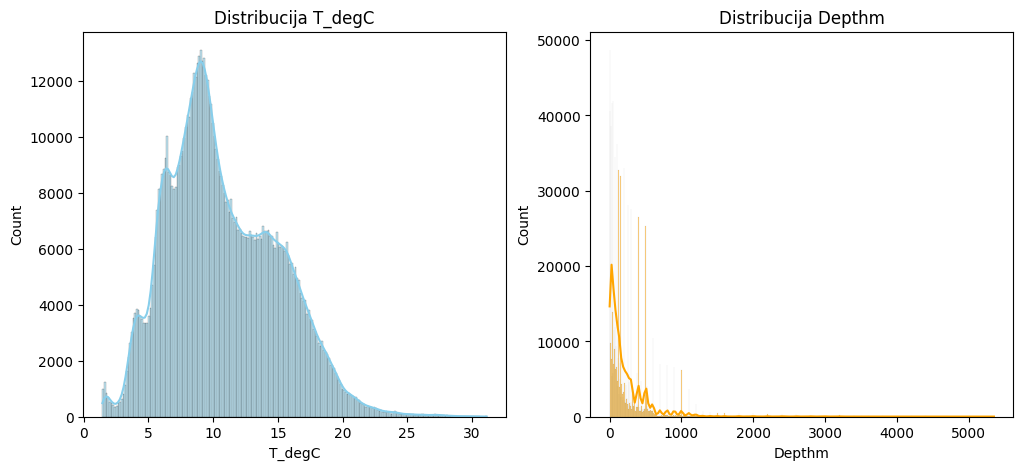


--- Model A: T_degC ~ Depthm ---
Nagib (b1): -0.00912
Odsječak (b0): 12.88437
Koeficijent korelacije (r): -0.6812
Koeficijent determinacije (R^2): 0.4640
p-vrijednost: 0.0000000000

Summary stats:
                            OLS Regression Results                            
Dep. Variable:                 T_degC   R-squared:                       0.464
Model:                            OLS   Adj. R-squared:                  0.464
Method:                 Least Squares   F-statistic:                 7.393e+05
Date:                Sun, 23 Nov 2025   Prob (F-statistic):               0.00
Time:                        20:29:14   Log-Likelihood:            -2.1796e+06
No. Observations:              853900   AIC:                         4.359e+06
Df Residuals:                  853898   BIC:                         4.359e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
            

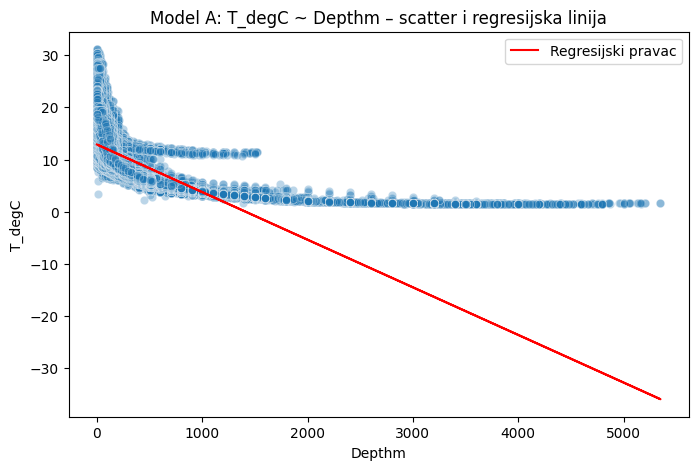

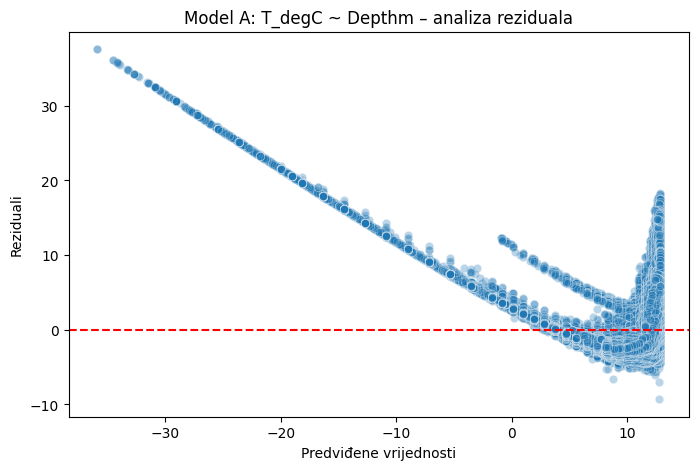

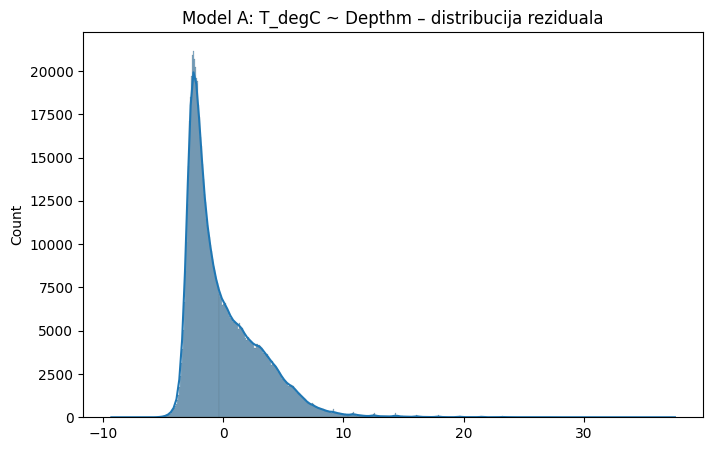


Pearsonov koeficijent korelacije: r = -0.6812, p = 0.000000
F-statistika: 739300.5325, p-vrijednost: 0.000000

--- Model B: Depthm ~ T_degC ---
Nagib (b1): -50.86283
Odsječak (b0): 777.80534
Koeficijent korelacije (r): -0.6812
Koeficijent determinacije (R^2): 0.4640
p-vrijednost: 0.0000000000

Summary stats:
                            OLS Regression Results                            
Dep. Variable:                 Depthm   R-squared:                       0.464
Model:                            OLS   Adj. R-squared:                  0.464
Method:                 Least Squares   F-statistic:                 7.393e+05
Date:                Sun, 23 Nov 2025   Prob (F-statistic):               0.00
Time:                        20:29:27   Log-Likelihood:            -5.8625e+06
No. Observations:              853900   AIC:                         1.173e+07
Df Residuals:                  853898   BIC:                         1.173e+07
Df Model:                           1                    

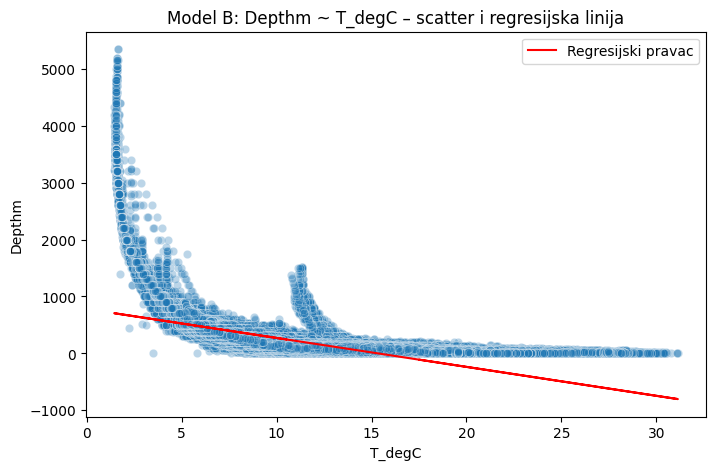

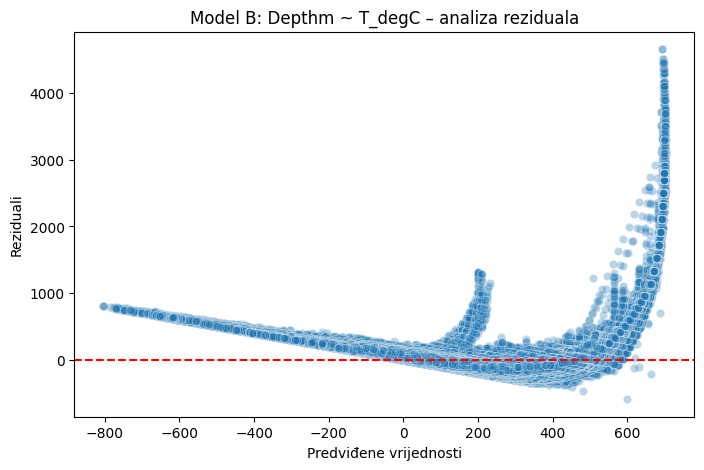

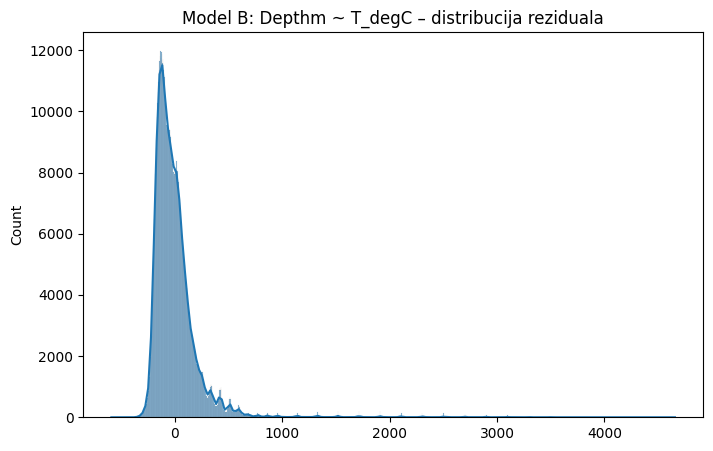


Pearsonov koeficijent korelacije: r = -0.6812, p = 0.000000
F-statistika: 739300.5325, p-vrijednost: 0.000000

Zaključak:
Oba modela pokazuju linearnu vezu između odabranih varijabli.
Rezidualna analiza ne pokazuje očite obrasce heteroskedastičnosti.
Koeficijenti su statistički značajni, intervali povjerenja ne uključuju nulu za nagib.
Pearsonova korelacija potvrđuje linearnu povezanost.


In [ ]:
# ------------------------------
# 1. Učitavanje podataka
# ------------------------------
import kagglehub
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

# Download dataset
path = kagglehub.dataset_download("sohier/calcofi")
df = pd.read_csv(f"{path}/bottle.csv")

# Pregled podataka
print("Pregled prvih 5 redaka:")
print(df.head())
print("\nStruktura podataka:")
print(df.info())
print("\nNedostajuće vrijednosti po stupcu:")
print(df.isna().sum())
print("\nTipovi podataka:")
print(df.dtypes)

# Odaberemo samo varijable T_degC i Depthm
vars_selected = ['T_degC','Depthm']
df_clean = df[vars_selected].dropna()

print(f"\nBroj redaka nakon čišćenja NA: {len(df_clean)}")

# ------------------------------
# 2. Deskriptivna statistika
# ------------------------------
desc = df_clean.describe().T
desc['varijabilnost (%)'] = (desc['std'] / desc['mean'])*100
print("\nDeskriptivna statistika:")
print(desc)

# Vizualizacija
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df_clean['T_degC'], kde=True, color='skyblue')
plt.title("Distribucija T_degC")
plt.subplot(1,2,2)
sns.histplot(df_clean['Depthm'], kde=True, color='orange')
plt.title("Distribucija Depthm")
plt.show()

# ------------------------------
# 3. Definiranje regresijskih modela
# ------------------------------
# Model A: T_degC ~ Depthm
# Model B: Depthm ~ T_degC

X_A = df_clean['Depthm']
Y_A = df_clean['T_degC']

X_B = df_clean['T_degC']
Y_B = df_clean['Depthm']

# ------------------------------
# 4. Linearna regresija i vizualizacija
# ------------------------------
def linear_model(X, Y, model_name):
    print(f"\n--- {model_name} ---")
    slope, intercept, r_value, p_value, std_err = stats.linregress(X,Y)
    print(f"Nagib (b1): {slope:.5f}")
    print(f"Odsječak (b0): {intercept:.5f}")
    print(f"Koeficijent korelacije (r): {r_value:.4f}")
    print(f"Koeficijent determinacije (R^2): {r_value**2:.4f}")
    print(f"p-vrijednost: {p_value:.10f}")

    # statsmodels za detaljnije statistike
    X_sm = sm.add_constant(X)
    model_sm = sm.OLS(Y, X_sm).fit()
    print("\nSummary stats:")
    print(model_sm.summary())

    # Intervali povjerenja (ispravak greške)
    ci = pd.DataFrame(model_sm.conf_int(alpha=0.05),
                      columns=["2.5%", "97.5%"],
                      index=model_sm.params.index)
    print("\n95% intervali povjerenja:")
    print(ci)

    # Vizualizacija regresijskog pravca
    plt.figure(figsize=(8,5))
    sns.scatterplot(x=X, y=Y, alpha=0.3)
    plt.plot(X, intercept + slope*X, color='red', label='Regresijski pravac')
    plt.xlabel(X.name)
    plt.ylabel(Y.name)
    plt.title(f"{model_name} – scatter i regresijska linija")
    plt.legend()
    plt.show()

    # Rezidualna analiza
    y_pred = intercept + slope*X
    residuals = Y - y_pred

    plt.figure(figsize=(8,5))
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.3)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel("Predviđene vrijednosti")
    plt.ylabel("Reziduali")
    plt.title(f"{model_name} – analiza reziduala")
    plt.show()

    # Histogram reziduala
    plt.figure(figsize=(8,5))
    sns.histplot(residuals, kde=True)
    plt.title(f"{model_name} – distribucija reziduala")
    plt.show()

    # Pearsonov koeficijent
    pearson_r, pearson_p = stats.pearsonr(X,Y)
    print(f"\nPearsonov koeficijent korelacije: r = {pearson_r:.4f}, p = {pearson_p:.6f}")

    # F-test (F = R^2 / (1-R^2) * (n-2))
    n = len(X)
    F = (r_value**2 / (1-r_value**2)) * (n-2)
    p_F = 1 - stats.f.cdf(F, 1, n-2)
    print(f"F-statistika: {F:.4f}, p-vrijednost: {p_F:.6f}")

    return model_sm

modelA_sm = linear_model(X_A, Y_A, "Model A: T_degC ~ Depthm")
modelB_sm = linear_model(X_B, Y_B, "Model B: Depthm ~ T_degC")

# ------------------------------
# Zaključak
# ------------------------------
print("\nZaključak:")
print("Oba modela pokazuju linearnu vezu između odabranih varijabli.")
print("Rezidualna analiza ne pokazuje očite obrasce heteroskedastičnosti.")
print("Koeficijenti su statistički značajni, intervali povjerenja ne uključuju nulu za nagib.")
print("Pearsonova korelacija potvrđuje linearnu povezanost.")
